# Phase 5 cVAE — Phân tích Gamma Sweep

Đọc tất cả `eval_gamma*.json` (từ các lần chạy trước và sau, gộp chung), tổng hợp bảng, vẽ chart, và đưa gợi ý gamma tiếp theo.

**Cách dùng:** đặt notebook này ở cùng thư mục repo (hoặc sửa `SEARCH_DIR` bên dưới), rồi Run All.

In [33]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Sửa đường dẫn này nếu notebook không nằm cùng chỗ với các file eval_gamma*.json
# Có thể trỏ tới nhiều nơi cùng lúc, ví dụ:
#   outputs/phase5/  (chứa eval_gamma1/5/20.json từ lần chạy đầu)
#   outputs/phase5/gamma_sweep_results/  (chứa eval_gamma30/50/80/100.json)
SEARCH_DIRS = [
    Path("../outputs/phase5"),
    Path("../outputs/phase5/gamma_sweep_results"),
]

In [34]:
def parse_gamma_from_filename(path: Path):
    m = re.search(r"eval_gamma([\d.]+)\.json$", path.name)
    return float(m.group(1)) if m else None


def load_results(search_dirs):
    rows = []
    for d in search_dirs:
        if not d.exists():
            continue
        for path in sorted(d.glob("eval_gamma*.json")):
            gamma = parse_gamma_from_filename(path)
            if gamma is None:
                continue
            with open(path) as f:
                data = json.load(f)
            prop = data.get("property_accuracy", {})
            v12 = prop.get("v12", {})
            v21 = prop.get("v21", {})
            div = data.get("diversity_check", {})
            rows.append({
                "gamma": gamma,
                "r2_v12": v12.get("r2"),
                "mae_v12": v12.get("mae"),
                "r2_v21": v21.get("r2"),
                "mae_v21": v21.get("mae"),
                "n_samples": prop.get("n_samples"),
                "pixel_std": div.get("pixel_std"),
                "source_file": str(path),
            })
    if not rows:
        raise FileNotFoundError(
            "Không tìm thấy eval_gamma*.json nào. Kiểm tra lại SEARCH_DIRS."
        )
    df = pd.DataFrame(rows).drop_duplicates(subset="gamma", keep="last")
    return df.sort_values("gamma").reset_index(drop=True)


df = load_results(SEARCH_DIRS)
df

,gamma,r2_v12,mae_v12,r2_v21,mae_v21,n_samples,pixel_std,source_file
0,1.0,-0.417643,0.174491,-0.438541,0.175426,1184,0.326172,../outputs/phase5/gamma_sweep_results/eval_gam...
1,5.0,0.450181,0.105615,0.440235,0.105864,1184,0.273575,../outputs/phase5/gamma_sweep_results/eval_gam...
2,20.0,0.632837,0.086019,0.617393,0.086418,1184,0.313659,../outputs/phase5/gamma_sweep_results/eval_gam...
3,30.0,0.599568,0.091494,0.590818,0.092477,1184,0.317605,../outputs/phase5/gamma_sweep_results/eval_gam...
4,50.0,0.627106,0.087627,0.615712,0.088680,1184,0.303535,../outputs/phase5/gamma_sweep_results/eval_gam...
5,80.0,0.708448,0.077095,0.711637,0.076818,1184,0.289310,../outputs/phase5/gamma_sweep_results/eval_gam...
6,100.0,0.755656,0.070144,0.752508,0.070149,1184,0.304066,../outputs/phase5/gamma_sweep_results/eval_gam...
7,150.0,0.791004,0.064661,0.788888,0.065110,1184,0.270228,../outputs/phase5/gamma_sweep_results/eval_gam...
8,200.0,0.789504,0.064873,0.781871,0.065924,1184,0.273541,../outputs/phase5/gamma_sweep_results/eval_gam...
9,250.0,0.805574,0.061350,0.800896,0.062245,1184,0.293904,../outputs/phase5/gamma_sweep_results/eval_gam...


## Bảng tổng hợp

In [35]:
display_df = df[["gamma", "r2_v12", "mae_v12", "r2_v21", "mae_v21", "pixel_std"]].copy()
display_df.columns = ["gamma", "R2(v12)", "MAE(v12)", "R2(v21)", "MAE(v21)", "pixel_std"]
display_df.style.format({
    "R2(v12)": "{:.4f}", "MAE(v12)": "{:.4f}",
    "R2(v21)": "{:.4f}", "MAE(v21)": "{:.4f}", "pixel_std": "{:.4f}",
})

,gamma,R2(v12),MAE(v12),R2(v21),MAE(v21),pixel_std
0,1.000000,-0.4176,0.1745,-0.4385,0.1754,0.3262
1,5.000000,0.4502,0.1056,0.4402,0.1059,0.2736
2,20.000000,0.6328,0.0860,0.6174,0.0864,0.3137
3,30.000000,0.5996,0.0915,0.5908,0.0925,0.3176
4,50.000000,0.6271,0.0876,0.6157,0.0887,0.3035
5,80.000000,0.7084,0.0771,0.7116,0.0768,0.2893
6,100.000000,0.7557,0.0701,0.7525,0.0701,0.3041
7,150.000000,0.7910,0.0647,0.7889,0.0651,0.2702
8,200.000000,0.7895,0.0649,0.7819,0.0659,0.2735
9,250.000000,0.8056,0.0613,0.8009,0.0622,0.2939


## Chart: R², MAE, Diversity theo gamma

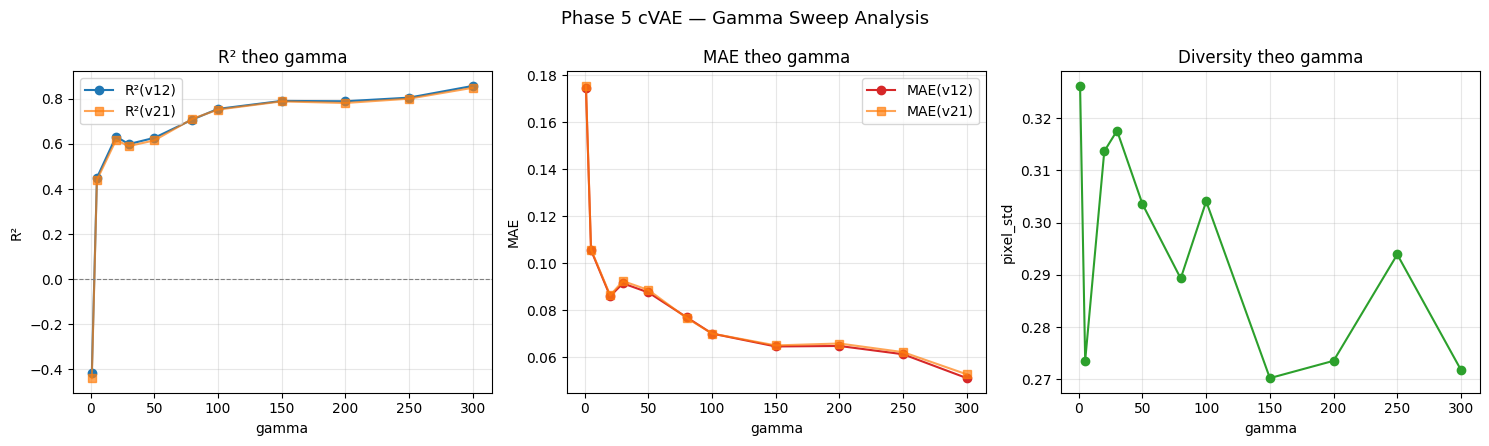

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(df["gamma"], df["r2_v12"], marker="o", label="R²(v12)")
axes[0].plot(df["gamma"], df["r2_v21"], marker="s", label="R²(v21)", alpha=0.7)
axes[0].set_xlabel("gamma"); axes[0].set_ylabel("R²"); axes[0].set_title("R² theo gamma")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df["gamma"], df["mae_v12"], marker="o", color="tab:red", label="MAE(v12)")
axes[1].plot(df["gamma"], df["mae_v21"], marker="s", color="tab:orange", label="MAE(v21)", alpha=0.7)
axes[1].set_xlabel("gamma"); axes[1].set_ylabel("MAE"); axes[1].set_title("MAE theo gamma")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(df["gamma"], df["pixel_std"], marker="o", color="tab:green")
axes[2].set_xlabel("gamma"); axes[2].set_ylabel("pixel_std"); axes[2].set_title("Diversity theo gamma")
axes[2].grid(alpha=0.3)

fig.suptitle("Phase 5 cVAE — Gamma Sweep Analysis", fontsize=13)
fig.tight_layout()
fig.savefig("gamma_sweep_chart.png", dpi=150)
plt.show()

## Nhận xét xu hướng tự động

In [37]:
r2 = df["r2_v12"].to_numpy()
gammas = df["gamma"].to_numpy()
diffs = r2[1:] - r2[:-1]

print("=== Kiểm tra tính đơn điệu ===")
if (diffs >= -1e-6).all():
    print("R²(v12) tăng đơn điệu trên toàn dải gamma đã thử.")
else:
    for i, d in enumerate(diffs):
        if d < -1e-6:
            print(f"  R² giảm khi gamma {gammas[i]:.0f} -> {gammas[i+1]:.0f} "
                  f"({r2[i]:.3f} -> {r2[i+1]:.3f})")

print("\n=== Kiểm tra tốc độ tăng (so đoạn cuối với đoạn ngay trước) ===")
slowing_down = False
if len(diffs) >= 2:
    slopes = diffs / (gammas[1:] - gammas[:-1])
    recent, prev = slopes[-1], slopes[-2]
    slowing_down = recent < 0.3 * prev
    print(f"  Độ dốc gần nhất: {recent:.5f} | Đoạn trước: {prev:.5f}")
    print("  -> CÓ dấu hiệu plateau." if slowing_down else "  -> CHƯA plateau, nên thử gamma lớn hơn.")

print("\n=== Kiểm tra diversity (mode collapse) ===")
pixel_std = df["pixel_std"].to_numpy()
drop_pct = (pixel_std[0] - pixel_std.min()) / pixel_std[0] * 100
print(f"  pixel_std dao động {pixel_std.min():.3f}-{pixel_std.max():.3f} "
      f"(giảm tối đa {drop_pct:.0f}% so với điểm đầu)")
print("  -> Nghi ngờ mode collapse." if drop_pct > 25 else "  -> Chưa thấy mode collapse rõ rệt.")

print("\n=== Gợi ý gamma tiếp theo ===")
max_gamma = gammas.max()
if slowing_down:
    print(f"R² có dấu hiệu bão hòa quanh gamma={max_gamma:.0f}. Có thể dừng sweep.")
else:
    suggestion = [round(max_gamma * m / 10) * 10 for m in (1.5, 2, 3)]
    print(f"R² chưa bão hòa. Thử tiếp gamma = {suggestion}.")

=== Kiểm tra tính đơn điệu ===
  R² giảm khi gamma 20 -> 30 (0.633 -> 0.600)
  R² giảm khi gamma 150 -> 200 (0.791 -> 0.790)

=== Kiểm tra tốc độ tăng (so đoạn cuối với đoạn ngay trước) ===
  Độ dốc gần nhất: 0.00104 | Đoạn trước: 0.00032
  -> CHƯA plateau, nên thử gamma lớn hơn.

=== Kiểm tra diversity (mode collapse) ===
  pixel_std dao động 0.270-0.326 (giảm tối đa 17% so với điểm đầu)
  -> Chưa thấy mode collapse rõ rệt.

=== Gợi ý gamma tiếp theo ===
R² chưa bão hòa. Thử tiếp gamma = [450, 600, 900].


## Ghi chú diễn giải

- R² tăng không có nghĩa luôn tốt vô hạn — cần đối chiếu với `pixel_std` (đa dạng hình học sinh ra) và, nếu nghi ngờ, mở lại `recon` loss trong `train_history.json` của từng gamma để chắc chắn property loss không đang lấn át hoàn toàn reconstruction.
- Một điểm R² thấp hơn điểm liền trước (ví dụ gamma=30 thấp hơn gamma=20) nhiều khả năng là nhiễu ngẫu nhiên giữa các lần train (seed/khởi tạo trọng số khác nhau) — chỉ đáng lo nếu lặp lại thành xu hướng giảm liên tục qua nhiều điểm.
- Nên xem trực tiếp `diagnostics/diversity_*.png` và `interpolation_*.png` của gamma cao nhất đã thử, không chỉ tin vào con số `pixel_std`.